In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import json

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
IMG_SIZE = 50
BATCH_SIZE = 32
data_dir = "/content/drive/MyDrive/Braaille Vision Hackathon/Braille Alphabet Image Dataset (A–Z)"

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [6]:
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    subset='training'
)

Found 2080 images belonging to 26 classes.


In [7]:
val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    subset='validation'
)

Found 520 images belonging to 26 classes.


In [8]:
print("Classes:", train_generator.class_indices)

Classes: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25}


In [9]:
num_classes = len(train_generator.class_indices)

model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 9, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         6,682 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 623,898 (2.38 MB)

 Trainable params: 623,898 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 482s 7s/step - accuracy: 0.3644 - loss: 2.1468 - val_accuracy: 1.0000 - val_loss: 0.1182
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - accuracy: 0.9183 - loss: 0.2376 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.9755 - loss: 0.0682 - val_accuracy: 1.0000 - val_loss: 4.6117e-04
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - accuracy: 0.9837 - loss: 0.0499 - val_accuracy: 1.0000 - val_loss: 2.2873e-04
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step - accuracy: 0.9885 - loss: 0.0344 - val_accuracy: 1.0000 - val_loss: 4.9461e-05
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step - accuracy: 0.9894 - loss: 0.0275 - val_accuracy: 1.0000 - val_loss: 5.5348e-05
Epoch 7/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - accuracy: 0.9937 - loss: 0.0212 - val_accuracy: 1.0000 - val_loss: 1.2394e-05
Epoch 8/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - accuracy: 0.9909 - loss: 0.0249

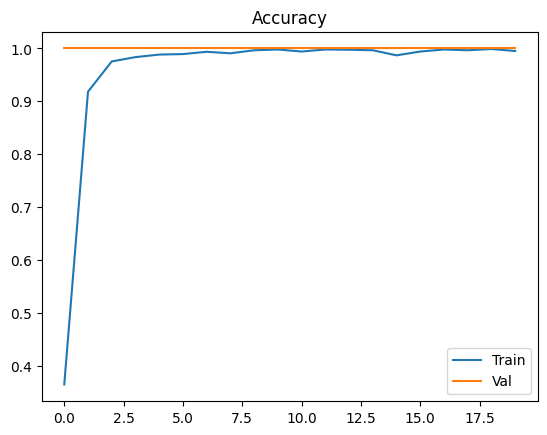

In [13]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.show()

In [45]:
model.save("/content/drive/MyDrive/Braaille Vision Hackathon/Hackathon/braille_cnn.h5")

class_indices = train_generator.class_indices
reverse_map = {str(v): k for k, v in class_indices.items()}

with open("/content/drive/MyDrive/Braaille Vision Hackathon/Hackathon/reverse_map.json", "w") as f:
    json.dump(reverse_map, f)

print("✅ Model saved!")
print("Classes:", reverse_map)

✅ Model saved!
Classes: {'0': 'A', '1': 'B', '2': 'C', '3': 'D', '4': 'E', '5': 'F', '6': 'G', '7': 'H', '8': 'I', '9': 'J', '10': 'K', '11': 'L', '12': 'M', '13': 'N', '14': 'O', '15': 'P', '16': 'Q', '17': 'R', '18': 'S', '19': 'T', '20': 'U', '21': 'V', '22': 'W', '23': 'X', '24': 'Y', '25': 'Z'}


In [44]:
import shutil
shutil.copy("/content/braille_cnn.onnx", "/content/drive/MyDrive/Braaille Vision Hackathon/Hackathon/braille_cnn.onnx")
print("✅ ONNX saved to Drive!")

✅ ONNX saved to Drive!


In [18]:
import cv2
import os

base = "/content/drive/MyDrive/Braaille Vision Hackathon/Braille Alphabet Image Dataset (A\u2013Z)"
folder = sorted(os.listdir(base))[0]
file = os.listdir(os.path.join(base, folder))[0]
test_path = os.path.join(base, folder, file)

img = cv2.imread(test_path, cv2.IMREAD_GRAYSCALE)
resized = cv2.resize(img, (50, 50))
normalized = resized / 255.0
ready = normalized.reshape(1, 50, 50, 1).astype(np.float32)

prediction = model.predict(ready)
class_index = str(np.argmax(prediction))
letter = reverse_map[class_index]
confidence = np.max(prediction) * 100

print(f"Folder: {folder}")
print(f"Predicted: {letter.upper()}")
print(f"Confidence: {confidence:.1f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 838ms/step
Folder: A
Predicted: A
Confidence: 100.0%
